In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from eQIF_utils import *

In [2]:
# Plot the results with custom font sizes for better readability
plt.rcParams.update({
'font.size': 20,          # Controls default text size
'axes.titlesize': 20,     # Title font size
'axes.labelsize': 20,     # X/Y label font size
'xtick.labelsize': 18,    # X tick labels
'ytick.labelsize': 18,    # Y tick labels
'legend.fontsize': 14,    # Legend font size
})

### Influence of the perturbation

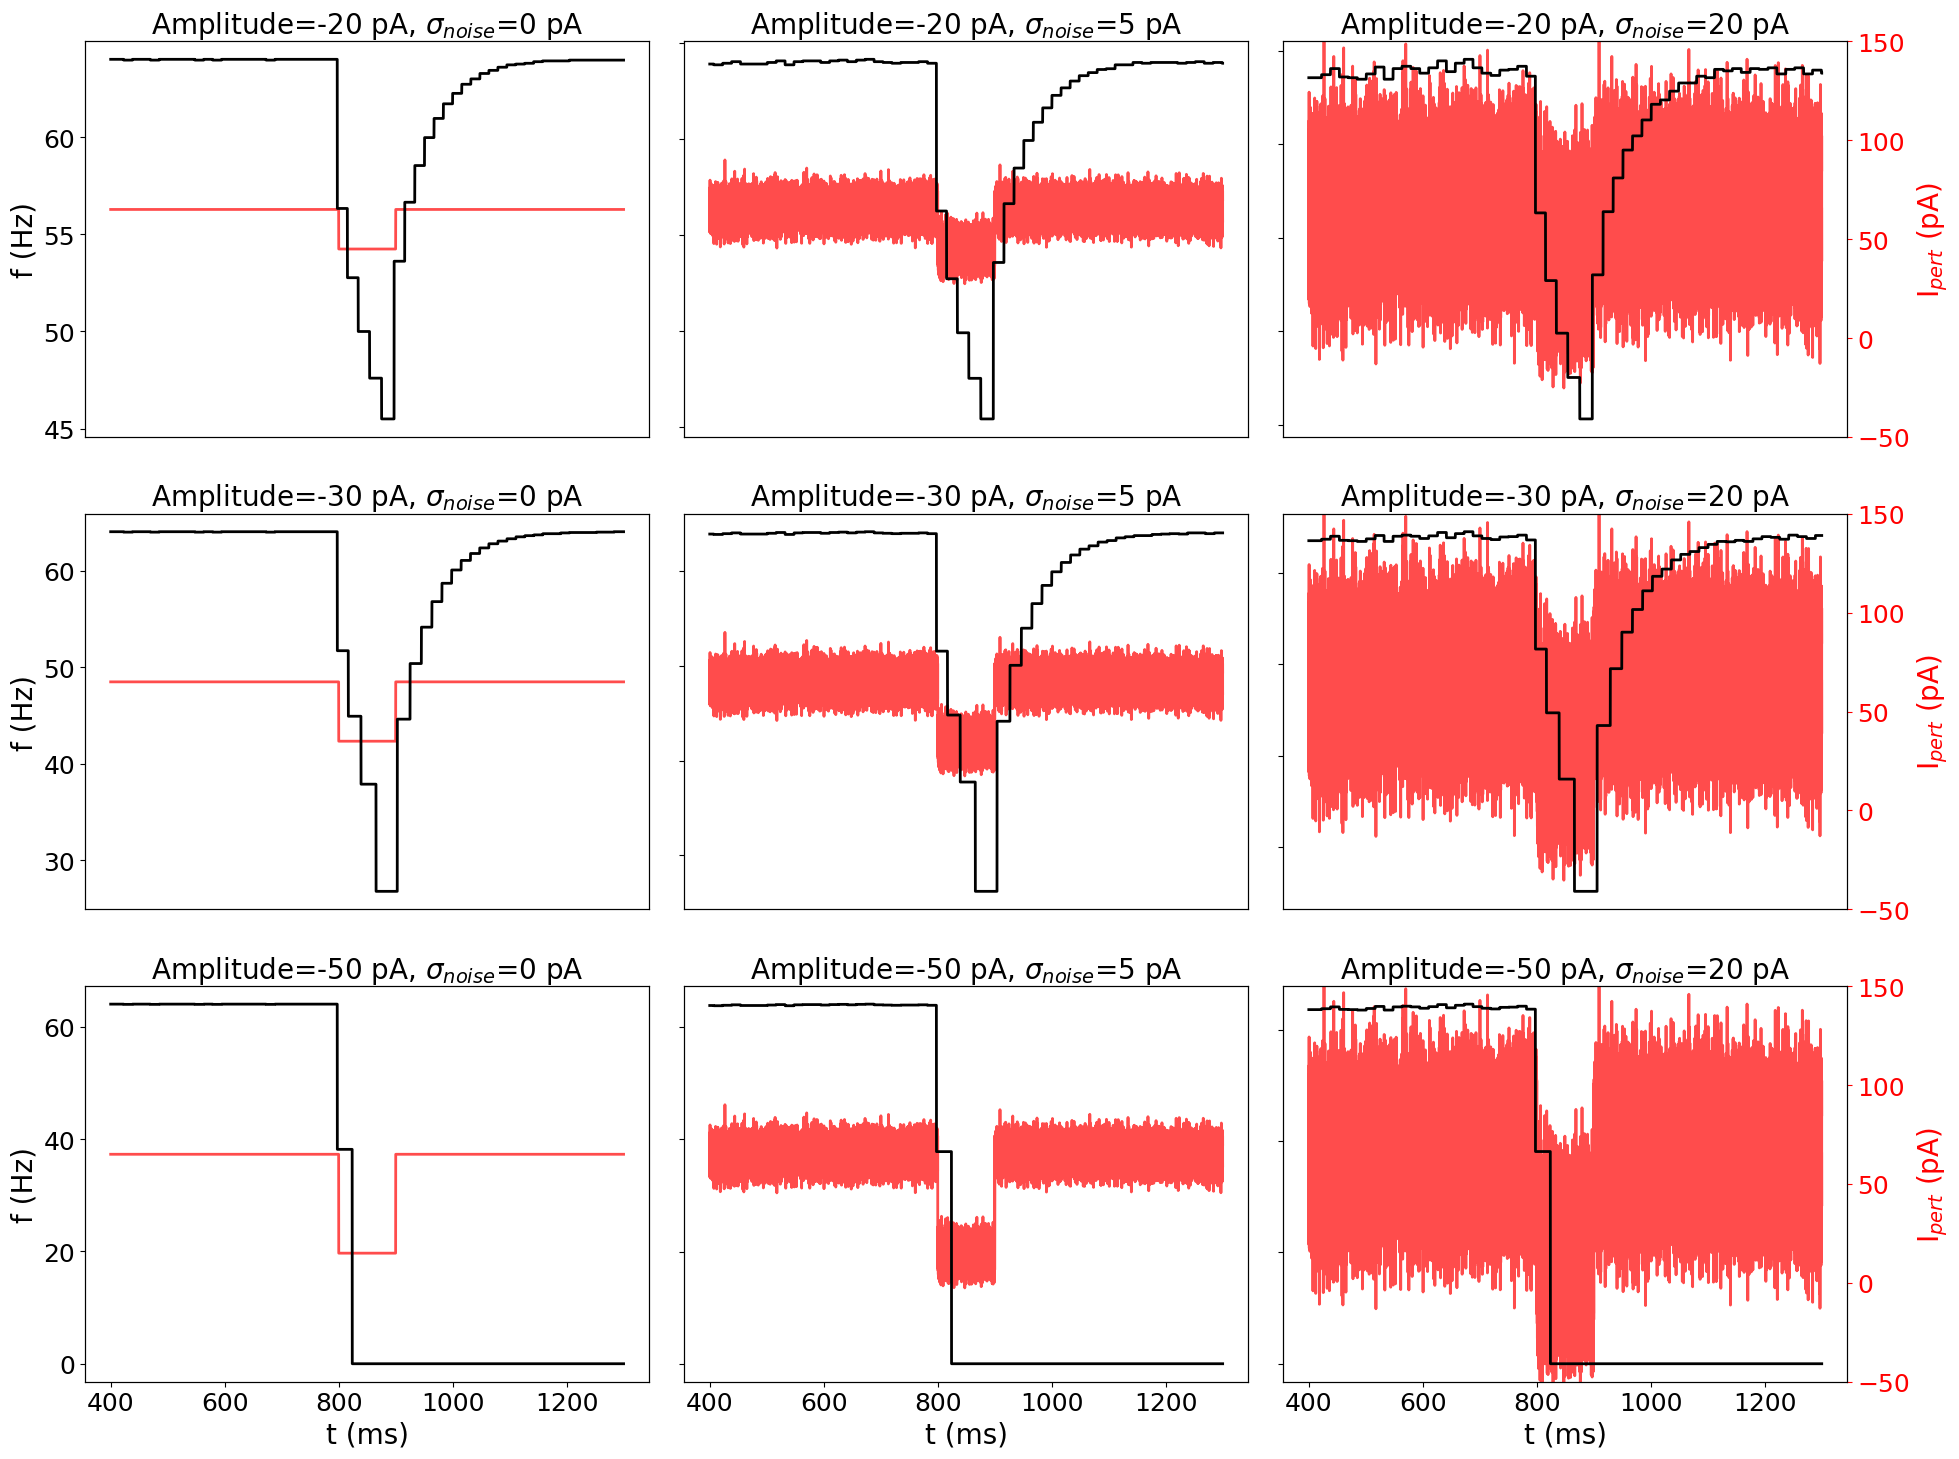

In [6]:
# Plot the response of the persistent state to perturbations of different amplitudes and noise levels.

# Define the parameters for the perturbation current and noise levels to test
amp_values = [20, 30, 50]
noise_values = [0, 5, 20]

# Define the time array for the simulation
dt = 0.01
duration = 1400
time_array = np.arange(0, duration + dt/2, dt)

fig, axs = plt.subplots(len(amp_values), len(noise_values), figsize=(20, 15))
for i, amp_val in enumerate(amp_values):
    for j, noise_val in enumerate(noise_values):
        pert_current = perturbation_current(time_array, Amp=-amp_val, tw=100, sigma_noise=noise_val, random_seed=42)
        V_sim, _, spikes_sim = variable_current_sim(time_array, pert_current, a=10, b=100, v0=-25, Iw0=100)
        inst_frequency = compute_instantaneous_freq(time_array, spikes_sim)

        tmask = (time_array >= 400) & (time_array <= 1300)

        ax = axs[i, j]
        ax.plot(time_array[tmask], inst_frequency[tmask], 'k', lw=2)

        # Left axis formatting
        ax.tick_params(axis='y', colors='black')
        if j == 0:
            ax.set_ylabel('f (Hz)', color='black')
        else:
            ax.set_yticklabels([])
            ax.tick_params(axis='y', left=False)

        # Right twin axis
        ax2 = ax.twinx()
        ax2.plot(time_array[tmask], pert_current[tmask], 'r', alpha=0.7, lw=2)
        ax2.set_ylim(-50, 150)

        ax2.tick_params(axis='y', colors='red')
        if j == len(noise_values) - 1:
            ax2.set_ylabel('I$_{pert}$ (pA)', color='red')
        else:
            ax2.set_yticklabels([])
            ax2.tick_params(axis='y', right=False)

        # Draw frequency (ax) on top of current (ax2)
        ax.set_zorder(ax2.get_zorder() + 1)
        ax.patch.set_visible(False)  # keep ax background transparent

        # Bottom x-axis
        if i == len(amp_values) - 1:
            ax.set_xlabel('t (ms)', color='black')
        else:
            ax.set_xticklabels([])
            ax.tick_params(axis='x', bottom=False)

        ax.set_title(f'Amplitude={-amp_val} pA, $\\sigma_{{noise}}$={noise_val} pA')

plt.tight_layout()
plt.show()

### Effect of perturbation on UP-to-DOWN and DOWN-to-UP transition
NOTE: UP refers to the PERSISTENT state, while DOWN refers to QUIESCENT state

In [ ]:
# Simulation to check the effective presence of a bistable regime
dt = 0.01
duration = 1500
time_array = np.arange(0, duration + dt/2, dt)
Iext = 65

V_sim_UP, _, spikes_sim_UP = variable_current_sim(time_array, np.ones(len(time_array))*Iext, a=10, b=100, v0=-25, Iw0=100)
instantaneous_freq = compute_instantaneous_freq(time_array, spikes_sim_UP)

plt.figure(figsize=(12, 6))
plt.plot(time_array, instantaneous_freq, 'b')
ax2 = plt.gca().twinx()
ax2.plot(time_array, V_sim_UP, 'r', alpha=0.5)
plt.show()

V_sim_DOWN, _, spikes_sim_DOWN = variable_current_sim(time_array, np.ones(len(time_array))*Iext, a=10, b=100, v0=-25, Iw0=-100)
instantaneous_freq = compute_instantaneous_freq(time_array, spikes_sim_DOWN)

plt.figure(figsize=(12, 6))
plt.plot(time_array, instantaneous_freq, 'b')
ax2 = plt.gca().twinx()
ax2.plot(time_array, V_sim_DOWN, 'r', alpha=0.5)
plt.show()

In [ ]:
# Parameter space exploration for the response to perturbations of different amplitudes and durations, starting from both the persistent and quiescent states
dt = 0.01
duration = 2000
time_array = np.arange(0, duration + dt/2, dt)

Ibase = 65
amp_values = np.arange(0, 90.5, 0.5)
tw_values = np.arange(10, 150.5, 0.5)

In [ ]:
# Compute the state matrices for the UP to DOWN and DOWN to UP transitions. 
# Compute also the corresponding boundaries (sh_up2down and sh_down2up) for visualization.
m_up2down, m_down2up, sh_up2down, sh_down2up = compute_state_matrices(time_array, amp_values, tw_values, Ibase=Ibase)

In [ ]:
# Color for 0=DOWN, 1=UP
cmap = ListedColormap(['#0072B2', '#E69F00'])  
# Boundaries between the 2 states
norm = BoundaryNorm([0, 0.5, 1], cmap.N)  

fig, axs = plt.subplots(1, 2, figsize=(25,10))

im0 = axs[0].imshow(m_up2down, cmap=cmap, norm=norm, aspect='auto')
axs[0].set_title('Initial Persistent State')

im1 = axs[1].imshow(m_down2up, cmap=cmap, norm=norm, aspect='auto')
axs[1].set_title('Initial Quiescent State')

for ax in axs:
    ax.set_xlabel('Perturbation Duration (ms)')
    ax.set_ylabel('Absolute Perturbation Amplitude (pA)')
    ax.set_xticks(np.arange(len(tw_values)))
    ax.set_xticklabels(tw_values)
    ax.set_yticks(np.arange(len(amp_values)))
    ax.set_yticklabels(amp_values)
    ax.invert_yaxis()

    stepx = 40 
    ax.set_xticks(np.arange(len(tw_values))[::stepx])
    ax.set_xticklabels(tw_values[::stepx])
    stepy = 15 
    ax.set_yticks(np.arange(len(amp_values))[::stepy])
    ax.set_yticklabels(amp_values[::stepy])


# Shared colorbar on the right
fig.colorbar(im1, ax=axs, location='right', label='State (0=Quiescent, 1=Persistent)')
plt.show()

plt.figure(figsize=(12, 8))
plt.plot([s[1] for s in sh_up2down], [s[0] for s in sh_up2down], color='#0072B2', lw=5, label='Persistent $\\to$ Quiescent')
plt.plot([s[1] for s in sh_down2up], [s[0] for s in sh_down2up], color='#E69F00', lw=5, label='Quiescent $\\to$ Persistent')
plt.xlabel('Perturbation Duration (ms)')
plt.xlim(0, 140)
plt.ylabel('Absolute Perturbation Amplitude (pA)')
plt.ylim(0, 90)
plt.legend()
plt.show()

### Noise influence on UP-to-DOWN and DOWN-to-UP transition

In [ ]:
# Define the parameters for the perturbation current and noise levels to test
dt = 0.01
duration = 1500
time_array = np.arange(0, duration + dt/2, dt)

Ibase = 65
amp_values = np.arange(0, 90.5, 0.5)
tw_values = np.arange(10, 150.5, 0.5)
noise_amplitudes = [0, 5, 50]

In [ ]:
sh_UP_to_DOWN_noisy = []
sh_DOWN_to_UP_noisy = []

# Compute the state matrices for the UP to DOWN and DOWN to UP transitions in the presence of noise, for different noise amplitudes.
for noise_amp in noise_amplitudes:
    _, _, sh_up2down, sh_down2up = compute_state_matrices(time_array, amp_values, tw_values, Ibase=Ibase, sigma=noise_amp, random_seed=42)
    sh_UP_to_DOWN_noisy.append(sh_up2down)
    sh_DOWN_to_UP_noisy.append(sh_down2up)

In [ ]:
plt.figure(figsize=(12, 8))
for i, noise_amp in enumerate(noise_amplitudes):
    sh_up2down = sh_UP_to_DOWN_noisy[i]
    plt.plot([s[1] for s in sh_up2down], [s[0] for s in sh_up2down], lw=5, label=f'$\sigma_{{noise}}$={noise_amp}')

plt.xlabel('Perturbation Duration (ms)')
plt.xlim(0, 120)
plt.ylabel('Absolute Perturbation Amplitude (pA)')
plt.ylim(0, 90)
plt.title('Persistent $\\rightarrow$ Quiescent Transition')
plt.legend()
plt.show()


plt.figure(figsize=(12, 8))
for i, noise_amp in enumerate(noise_amplitudes):
    sh_down2up = sh_DOWN_to_UP_noisy[i]
    plt.plot([s[1] for s in sh_down2up], [s[0] for s in sh_down2up], lw=5, label=f'$\sigma_{{noise}}$={noise_amp}')

plt.xlabel('Perturbation Duration (ms)')
plt.xlim(0, 120)
plt.ylabel('Absolute Perturbation Amplitude (pA)')
plt.ylim(0, 90)
plt.title('Quiescent $\\rightarrow$ Persistent Transition')
plt.legend()
plt.show()
